In [2]:
! pip install ruptures


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# =========================================================
# 0. 환경 설정
# =========================================================
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import ruptures as rpt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D,
    Dense, Flatten, Dropout, BatchNormalization
)

In [5]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# 1. 데이터 로드
# =========================================================
df = pd.read_csv("bearing_train_final.csv")
df_test = pd.read_csv("bearing_test_question.csv")

df.index.name = "elapsed_sec"
df_test.index.name = "elapsed_sec"

MAX_TIME = df.index.max()

In [6]:
# =========================================================
# 2. Sensor 기반 열화 신호 생성
# =========================================================
WINDOW_STAT = 200

def make_degradation_signals(df):
    df = df.copy()

    df["S1_rms"] = (
        df["Sensor_1"]
        .rolling(WINDOW_STAT)
        .apply(lambda x: np.sqrt(np.mean(x**2)), raw=True)
    )
    df["S1_var"] = df["Sensor_1"].rolling(WINDOW_STAT).var()

    df["S4_diff"] = df["Sensor_4"].diff()
    df["S4_diff_std"] = df["S4_diff"].rolling(WINDOW_STAT).std()

    return df.dropna()

df_sig = make_degradation_signals(df)

# =========================================================
# 3. Ruptures 기반 변화점 탐지
# =========================================================
def detect_change_point(signal, pen=10):
    algo = rpt.Pelt(model="rbf").fit(signal)
    cp = algo.predict(pen=pen)
    return cp[0]

cp_s1 = detect_change_point(df_sig["S1_rms"].values)
cp_s4 = detect_change_point(df_sig["S4_diff_std"].values)

# =========================================================
# 4. Threshold 기반 검증
# =========================================================
def threshold_degradation_start(series, baseline_end=15000, k=3):
    baseline = series.loc[series.index < baseline_end]
    mu, sigma = baseline.mean(), baseline.std()
    threshold = mu + k * sigma
    idx = series[series > threshold].index
    return idx[0] if len(idx) > 0 else np.inf

th_s1 = threshold_degradation_start(df_sig["S1_rms"])
th_s4 = threshold_degradation_start(df_sig["S4_diff_std"])

# =========================================================
# 5. 최종 열화 시작점 확정
# =========================================================
degradation_start = int(np.min([cp_s1, cp_s4, th_s1, th_s4]))
print(f"[INFO] Degradation start detected at t = {degradation_start}")

# =========================================================
# 6. Feature Engineering (degradation-aware)
# =========================================================
def degradation_progress(index, deg_start, max_time):
    return np.clip((index - deg_start) / (max_time - deg_start), 0, 1)

def make_features(df, deg_start, max_time):
    df = df.copy()

    df["S1_diff"] = df["Sensor_1"].diff()
    df["S4_diff"] = df["Sensor_4"].diff()

    for col in ["Sensor_2", "Sensor_3"]:
        df[col] = df[col] - df[col].rolling(200, min_periods=1).mean()

    df["elapsed_norm"] = df.index / max_time
    df["deg_progress"] = degradation_progress(df.index.values, deg_start, max_time)

    # Degradation energy (Sensor 1 + 4 요약)
    df["deg_energy"] = (
        0.6 * df_sig["S1_rms"] / df_sig["S1_rms"].rolling(500).mean()
      + 0.4 * df_sig["S4_diff_std"] / df_sig["S4_diff_std"].rolling(500).mean()
    )

    return df.dropna()

df_feat = make_features(df, degradation_start, MAX_TIME)
df_test_feat = make_features(df_test, degradation_start, MAX_TIME)

# =========================================================
# 7. RUL Baseline + Residual
# =========================================================
df_feat["RUL_baseline"] = 1.0 - df_feat["elapsed_norm"]
df_test_feat["RUL_baseline"] = 1.0 - df_test_feat["elapsed_norm"]

df_feat["RUL_residual"] = df_feat["RUL"] - df_feat["RUL_baseline"]

FEATURE_COLS = [
    "S1_diff",
    "Sensor_2",
    "Sensor_3",
    "S4_diff",
    "deg_energy",
    "deg_progress"
]

# =========================================================
# 8. Sliding Window
# =========================================================
WINDOW = 200

def make_windows(df, feature_cols, target_col=None):
    X, y = [], []
    values = df[feature_cols].values
    target = df[target_col].values if target_col else None

    for i in range(len(df) - WINDOW):
        X.append(values[i:i+WINDOW])
        if target_col:
            y.append(target[i+WINDOW-1])

    return np.array(X), np.array(y) if target_col else np.array(X)

X_train, y_train = make_windows(df_feat, FEATURE_COLS, "RUL_residual")
X_test = make_windows(df_test_feat, FEATURE_COLS, None)

# =========================================================
# 9. PHM 특화 CNN 모델
# =========================================================
def build_cnn():
    return Sequential([
        Conv1D(32, 9, activation="relu", input_shape=(WINDOW, len(FEATURE_COLS))),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(64, 5, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(128, 3, activation="relu"),
        BatchNormalization(),

        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1)
    ])

# =========================================================
# 10. Physics-aware Loss (Monotonic)
# =========================================================
def rul_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mono = tf.reduce_mean(tf.nn.relu(y_pred[1:] - y_pred[:-1]))
    return mae + 0.2 * mono

model = build_cnn()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=rul_loss
)

# =========================================================
# 11. Sample Weight (열화 구간 강조)
# =========================================================
sample_weight = 0.5 + df_feat["deg_progress"].values[WINDOW:]

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    sample_weight=sample_weight,
    verbose=1
)

# =========================================================
# 12. 테스트 예측
# =========================================================
residual_pred = model.predict(X_test).flatten()
baseline = df_test_feat["RUL_baseline"].values[WINDOW:]
y_pred = baseline + residual_pred

# 단조 감소 보정
for i in range(1, len(y_pred)):
    y_pred[i] = min(y_pred[i], y_pred[i-1])

y_pred = np.clip(y_pred, 0, 1)


[INFO] Degradation start detected at t = 20


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.3930
Epoch 2/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.1571
Epoch 3/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0510
Epoch 4/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0167
Epoch 5/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0123
Epoch 6/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0108
Epoch 7/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0101
Epoch 8/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0103
Epoch 9/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0096
Epoch 10/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0101
Epoch 11/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0095
Epoch 12/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0092
Epoch 13/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0094
Epoch 14/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0095
Epoch 15/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/s

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(32, 200, 6))', 'Tensor(shape=(32, 200, 6))')
  warnings.warn(msg)
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(None, 200, 6))', 'Tensor(shape=(None, 200, 6))')
  warnings.warn(msg)


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


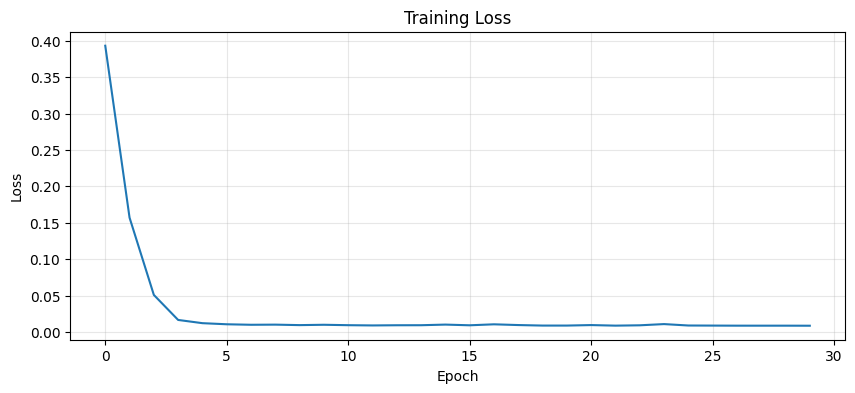

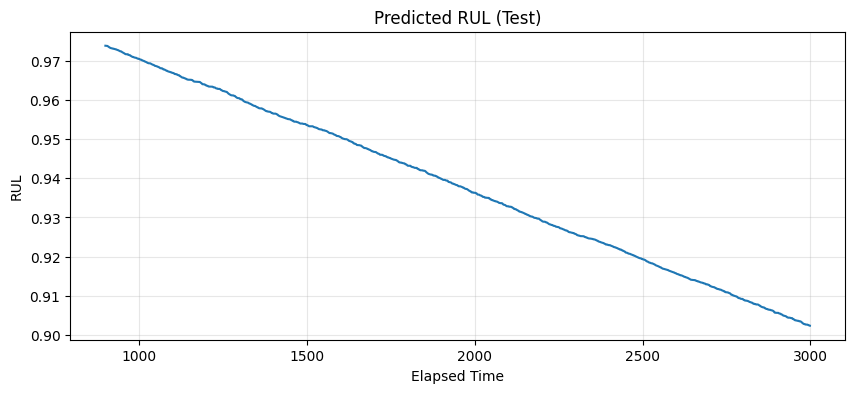

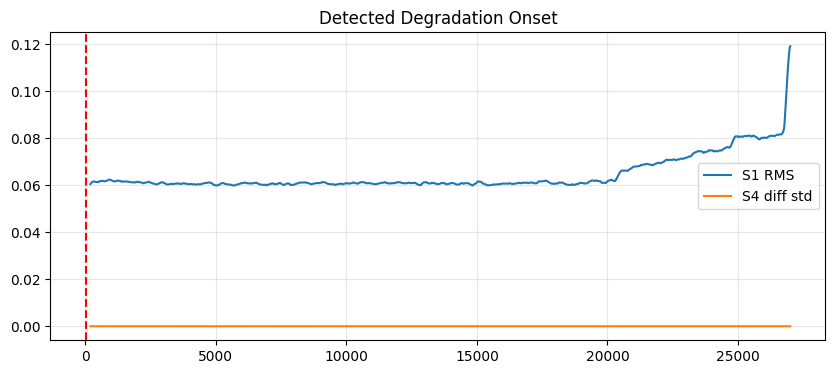

In [12]:
# =========================================================
# 13. 시각화
# =========================================================
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df_test_feat.index[WINDOW:], y_pred)
# plt.plot(df['RUL'], color = 'red')
plt.title("Predicted RUL (Test)")
plt.xlabel("Elapsed Time")
plt.ylabel("RUL")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.axvline(degradation_start, color="r", linestyle="--")
plt.plot(df_sig.index, df_sig["S1_rms"], label="S1 RMS")
plt.plot(df_sig.index, df_sig["S4_diff_std"], label="S4 diff std")
plt.legend()
plt.title("Detected Degradation Onset")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# =========================================================
# 14. 제출 파일 저장
# =========================================================
submission = pd.DataFrame(
    {"RUL": y_pred},
    index=df_test_feat.index[WINDOW:]
)
submission.to_csv("bearing_test_prediction_final.csv")
print("Saved: bearing_test_prediction_final.csv")